# Initialize data

In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from skimage import filters, exposure
from skimage.filters import threshold_local
from scipy import ndimage as ndi
from PIL import Image
import os
import io
import random
from IPython.display import Image as IPyImage, display
from unet import *


In [3]:
# tiff_path = "./data/EFR/Greyscale/EFRGP01_00.tif"
tiff_path = "./data_yukiko/images/monotonic/triax.0.eps=-0.0025.spheres_image_gaussian=08_noise=03.tif"

with tifffile.TiffFile(tiff_path) as tif:
    image = tif.asarray()
    print(f"Dimensions : {image.shape}")
    print(f"Type : {image.dtype}")

Dimensions : (122, 122, 122)
Type : uint16


Shape sous-volume : (100, 100, 100)


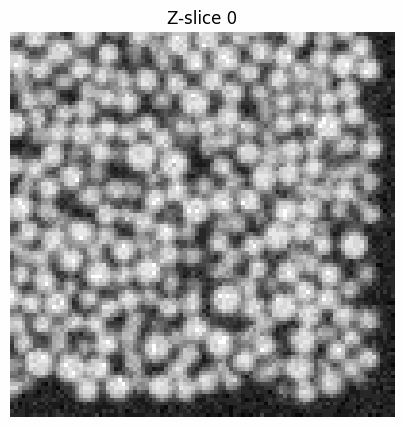

In [4]:
def extract_subvolume(image, region_size=100, offset_range=50):
    d, h, w = image.shape
    cz, cy, cx = d//2, h//2, w//2
    oz, oy, ox = [random.randint(-offset_range, offset_range) for _ in range(3)]

    sz = np.clip(cz + oz - region_size//2, 0, d - region_size)
    sy = np.clip(cy + oy - region_size//2, 0, h - region_size)
    sx = np.clip(cx + ox - region_size//2, 0, w - region_size)

    return image[sz:sz+region_size, sy:sy+region_size, sx:sx+region_size]

data = extract_subvolume(image, region_size=100)
print("Shape sous-volume :", data.shape)

def display_gif(zone) :
    slice_indices = [a for a in range(100)]
    frames = []
    
    for slice_idx in slice_indices:
        fig, ax = plt.subplots(figsize=(5, 5))
        im = ax.imshow(zone[slice_idx], cmap='gray', interpolation='nearest')
        ax.set_title(f'Z-slice {slice_idx}')
        ax.axis('off')
    
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        plt.close(fig)
        
        buf.seek(0)
        frame = Image.open(buf)
        frames.append(frame)
    
    # Save as GIF in-memory
    gif_buf = io.BytesIO()
    frames[0].save(gif_buf, format='GIF', save_all=True, append_images=frames[1:], duration=100, loop=0)
    gif_buf.seek(0)
        
    # Display the GIF in notebook
    display(IPyImage(data=gif_buf.read()))

display_gif(data)

# Normalization

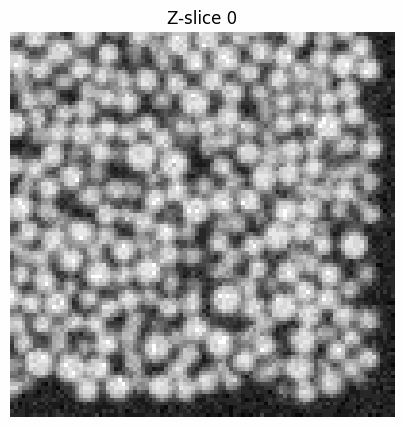

In [7]:
def normalize_image(imgs):
    
    # on garde que les valeurs positives pour la normalisation
    positive_vals = imgs[imgs > 0]
    mu = np.mean(positive_vals)
    sigma = np.std(positive_vals)
    
    # on mets la normalisation 
    norm_imgs = (imgs - mu) / (5 * sigma)
    
    # Remettre à zéro les valeurs initialement nulles
    norm_imgs[imgs == 0] = 0
    return norm_imgs

data_normalized = normalize_image(data)
display_gif(data_normalized)